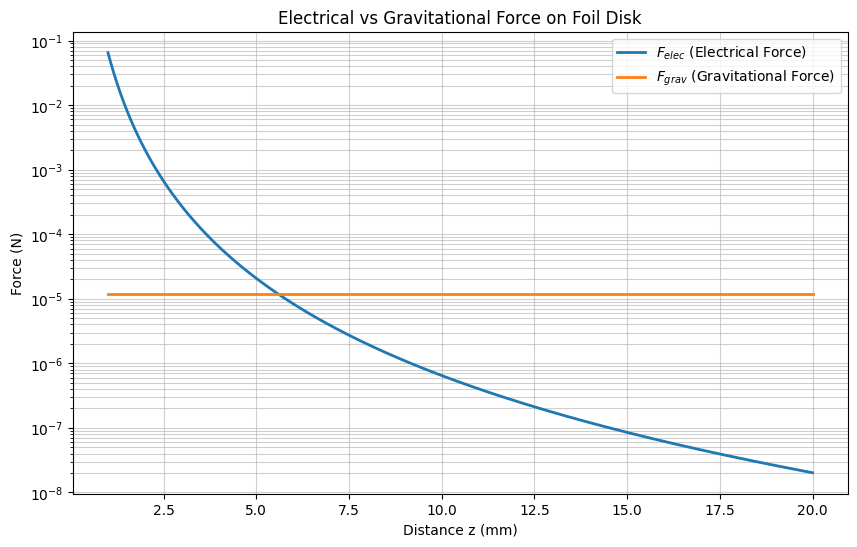

Numerical liftoff height: 5.584 mm


In [9]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81 # m/s
Q = 10e-9 # C
rho = 2700 # kg/m^3
epsilon0 = 8.85e-12 # C^2/N*m^2

r = 3e-3 # m
t = 0.016e-3 # m
V = np.pi * r * r * t
weight = rho * V * g

z_vals = np.linspace(1e-3, 20e-3, 1000)
F_grav = np.ones(1000) * weight
F_elec = np.zeros(1000)

for i in range(1000):
  z = z_vals[i]
  F_elec[i] = Q * Q * V / (8 * np.pi * np.pi * epsilon0 * z ** 5)

plt.figure(figsize=(10, 6))
plt.plot(z_vals * 1000, F_elec, label='$F_{elec}$ (Electrical Force)', linewidth=2)

plt.plot(z_vals * 1000, F_grav, label='$F_{grav}$ (Gravitational Force)', linewidth=2)

plt.yscale('log')

plt.xlabel('Distance z (mm)')
plt.ylabel('Force (N)')
plt.title('Electrical vs Gravitational Force on Foil Disk')
plt.legend()
plt.grid(True, which="both", alpha=0.6)

plt.show()

intersection_index = np.argmin(np.abs(F_elec - F_grav))
z_liftoff = z_vals[intersection_index]

print(f"Numerical liftoff height: {z_liftoff * 1000:.3f} mm")

In [13]:
num_points = 30
x_vals = np.linspace(-r, r, num_points)
y_vals = np.linspace(-r, r, num_points)

dx = x_vals[1] - x_vals[0]
dy = y_vals[1] - y_vals[0]
dV = dx * dy * t

total_upward_force = 0.0
valid_patches = 0

for x in x_vals:
    for y in y_vals:
        if x**2 + y**2 <= r**2:
            valid_patches += 1

            denominator_field = (x**2 + y**2 + z_liftoff**2)**1.5
            E_z = (Q * z_liftoff) / (4 * np.pi * epsilon0 * denominator_field)

            denominator_grad = (x**2 + y**2 + z_liftoff**2)**2.5
            numerator_grad = x**2 + y**2 - 2 * z_liftoff**2
            grad_E_z = abs((Q / (4 * np.pi * epsilon0)) * (numerator_grad / denominator_grad))

            dF = (epsilon0 * E_z * dV) * grad_E_z
            total_upward_force += dF

print(f"Total Weight of Foil:      {weight:.4e} N")
print(f"Total Integrated F_elec:   {total_upward_force:.4e} N")

if total_upward_force > weight:
    print("Result: The force IS enough to lift the foil.")
else:
    print("Result: The force is NOT enough to lift the foil.")

ideal_F_elec = weight
percentage_reduction = ((ideal_F_elec - total_upward_force) / ideal_F_elec) * 100
print(f"Reduction due to edge effects: {percentage_reduction:.2f}%")

Total Weight of Foil:      1.1982e-05 N
Total Integrated F_elec:   6.8266e-06 N
Result: The force is NOT enough to lift the foil.
Reduction due to edge effects: 43.03%
